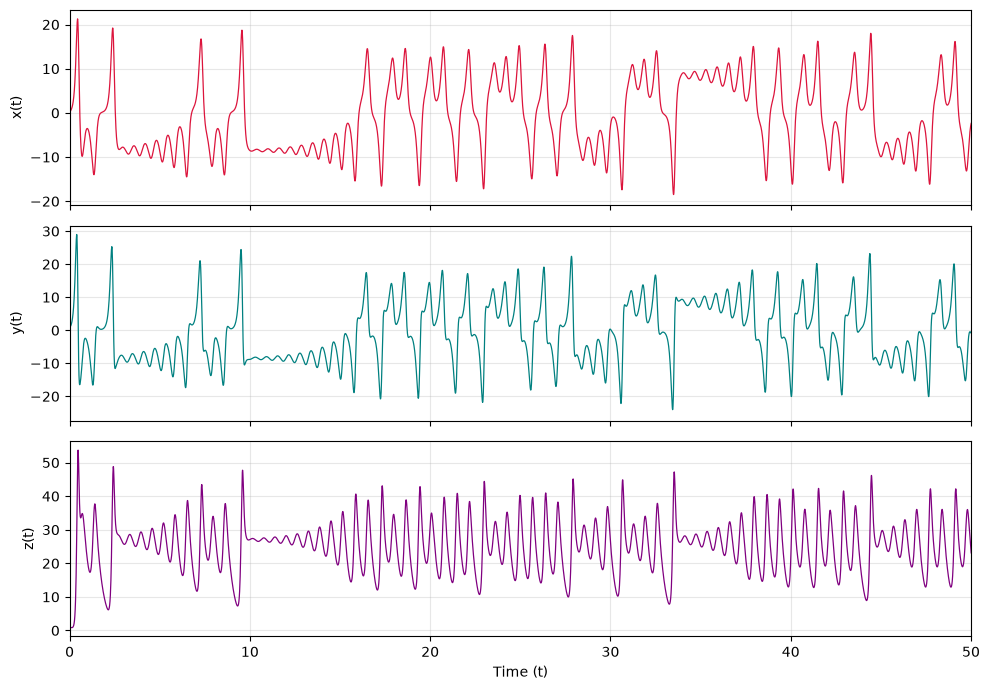

(8, 8)
(8,)
(9994, 9994)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.linalg import svd

def lorentz (xyz, s=10, r=28, b=2.667) :

    """
    Parameter
    ---------
    xyz : array, shape (3,)

    s,r,b : float
    Lorentz attarractor's parameter 
    """
    x,y,z = xyz
    x_dot = s*(y-x)
    y_dot = r*x - y -x*z
    z_dot = x*y - b*z

    return np.array([x_dot, y_dot, z_dot])

def lorentz_trajectory ():

    """
    Variable
    ---------
    dt : delta t for small changes in time
    num_steps : total time of trjectory

    Input : Use lorentz function to compute 
    Output : 1D array x,y,z trajectory with shape (10001,)
             2D array xyzs with shape (1001,3)
    
    
    """

    dt = 0.01
    num_steps = 10000
    xyzs =np.empty((num_steps+1,3))
    xyzs[0] = (0.,1.0,1.05)

    for i in range(num_steps):
        xyzs[i+1] = xyzs[i] + lorentz(xyzs[i]) * dt

    x = xyzs[:,0]
    y = xyzs[:,1]
    z = xyzs[:,2]
    t = np.arange(num_steps+1)* dt

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot( t,x, color="crimson", lw=0.9)
    axes[0].set_ylabel("x(t)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot( t,y, color="teal", lw=0.9)
    axes[1].set_ylabel("y(t)")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot( t,z, color="purple", lw=0.9)
    axes[2].set_ylabel("z(t)")
    axes[2].set_xlabel("Time (t)")
    axes[2].grid(True, alpha=0.3)

    plt.xlim(0, 50)
    plt.tight_layout()
    plt.show()

    return x,y,z, xyzs

def Hankel (var,n_delay):
    """
    Parameter
    ---------
    n_delay: number of delay
    var: 1D array var

    Output: Hankel matrix of var
    """

    N = len(var)
    num_cols = N - n_delay + 1

    first_col = var[:n_delay]
    last_row = var[n_delay-1:]

    return hankel(first_col,last_row)

x, y, z, xyzs = lorentz_trajectory()

x_hankel = Hankel(x,8)

u,s,v = svd(x_hankel)
print(u.shape)
print(s.shape)
print(v.shape)



